In [73]:
import numpy as np

In [74]:
import pandas as pd

In [75]:
df = pd.read_csv("./Data/exam.txt",header=None)
df.head()

,0,1,2
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


In [78]:
df.columns = ["t1","t2","target"]
newdf = df.sample(frac=1,random_state=42)
newdf.head()

,t1,t2,target
56,-0.21947,-0.016813,1
89,-0.38076,0.918860,0
4,-0.51325,0.465640,1
45,0.57546,0.268270,1
26,0.46601,-0.535820,1


In [79]:
x = np.array(newdf.iloc[:,:-1])
y = np.array(newdf.iloc[:,-1]).ravel()
##70:30 split
x_train_set = x
y_train_set = y

In [80]:
##gaussian naive bayes
probabilties = {}
targets = np.unique(y_train_set)
for value in targets:
    probabilties[value] = np.sum(y_train_set == value) / len(y_train_set)
probabilties


{0: 0.5084745762711864, 1: 0.4915254237288136}

In [81]:
def predictions(test_example):
    probs = {}
    for result in probabilties.keys():
        filtered_Data = x_train_set[y_train_set==result]
        logsum = 0
        for feature_index in range(x_train_set.shape[1]):
            filtered_Data_index = filtered_Data[:,feature_index].ravel()
            mean = np.mean(filtered_Data_index)
            std = np.std(filtered_Data_index)+1e-6
            x = test_example[feature_index]
            z = (x-mean)/std
            gaussian = 1/(np.sqrt(2*np.pi)*std)*np.exp(-1/2*((z)**2))
            logsum = logsum+np.log(gaussian)
        logprob = np.log(probabilties[result])+logsum
        probs[result] = np.exp(logprob)
    max_key = max(probs, key=probs.get)
    return max_key

In [82]:
import numpy as np

x_min, x_max = x_train_set[:,0].min()-1, x_train_set[:,0].max()+1
y_min, y_max = x_train_set[:,1].min()-1, x_train_set[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

In [83]:
grid_points = np.c_[xx.ravel(), yy.ravel()]

In [84]:
z = []
for point in grid_points:
    predicted_Val = predictions(point)
    z.append(predicted_Val)
z = np.array(z).reshape(xx.shape)

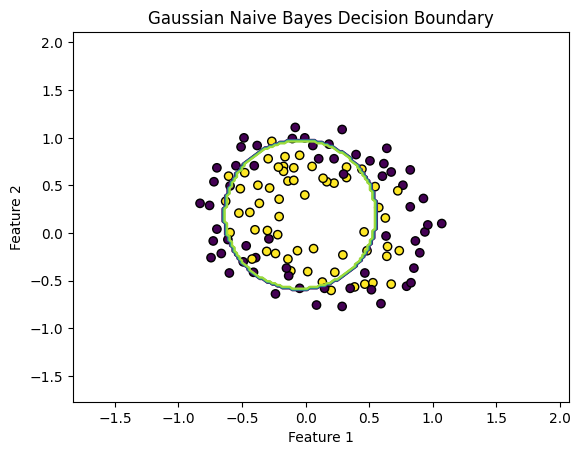

In [85]:
import matplotlib.pyplot as plt

plt.contour(xx, yy, z, alpha=1)
plt.scatter(x_train_set[:,0], x_train_set[:,1], c=y_train_set, edgecolor='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Gaussian Naive Bayes Decision Boundary")

plt.show()